In [2]:
import pandas as pd
import numpy as np
root="/home/jacoponudo/Documents/Virality-on-Shorts/" # TO CHANGE according to your local path

# Carichiamo i dataset puliti
instagram = pd.read_csv(root + "data/clean/instagram.csv")
tiktok = pd.read_csv(root + "data/clean/tiktok.csv")
youtube = pd.read_csv(root + "data/clean/youtube.csv")

# Filtriamo i publisher attivi per ogni piattaforma
from tools import filter_active_publisher_years
youtube_active, yt_publishers, yt_counts = filter_active_publisher_years(
    df=youtube,
    platform_name="YouTube",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=70
)

instagram_active, ig_publishers, ig_counts = filter_active_publisher_years(
    df=instagram,
    platform_name="Instagram",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=70
)

tiktok_active, tt_publishers, tt_counts = filter_active_publisher_years(
    df=tiktok,
    platform_name="TikTok",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=70
)


# Selezioniamo le colonne di interesse
tiktok=tiktok_active[['video_id','publisher', 'year','views','platform']]
youtube=youtube_active[['video_id','publisher', 'year','views','platform']]
instagram=instagram_active[['video_id','publisher', 'year','views','platform']]

tiktok['views'] =np.log(tiktok['views'].astype(int) + 1)
youtube['views'] =np.log(youtube['views'].astype(int) + 1)
instagram['views'] =np.log(instagram['views'].astype(int) + 1)


YouTube
-------
Original videos:              51,863
Original publishers:          130
Videos after filtering:       47,185
Unique publishers retained:   53

Publisher-years retained by year:
year
2022     8
2023    17
2024    24
2025    42
2026    39
Name: count, dtype: int64

Instagram
---------
Original videos:              235,743
Original publishers:          161
Videos after filtering:       227,976
Unique publishers retained:   130

Publisher-years retained by year:
year
2022     30
2023     97
2024    103
2025    121
2026    103
Name: count, dtype: int64

TikTok
------
Original videos:              195,672
Original publishers:          160
Videos after filtering:       189,948
Unique publishers retained:   119

Publisher-years retained by year:
year
2022    28
2023    60
2024    76
2025    94
2026    86
Name: count, dtype: int64


Preview of channel-year summary table:
    platform  publisher  year  n_videos_original  bvalue_mean  bvalue_ci_low  \
0  Instagram      AMICA  2023                101     1.604468       1.145942   
1  Instagram      AMICA  2024                189     1.194176       0.821624   
2  Instagram      AMICA  2025                243     1.047581       0.698402   
3  Instagram      AMICA  2026                103     1.133237       0.779215   
4  Instagram  Adnkronos  2023                128     1.573172       0.949412   

   bvalue_ci_high  
0        2.409534  
1        1.761201  
2        1.853401  
3        1.741799  
4        2.717541  

Total channel-years analyzed: 928
Percentile di completezza (x_min) usato: 70° percentile

OPTION A - Gutenberg-Richter b-value
             Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   bvalue_mean
No. Observations:   928       Method:               REML       
No. Groups:         285       Scale:                

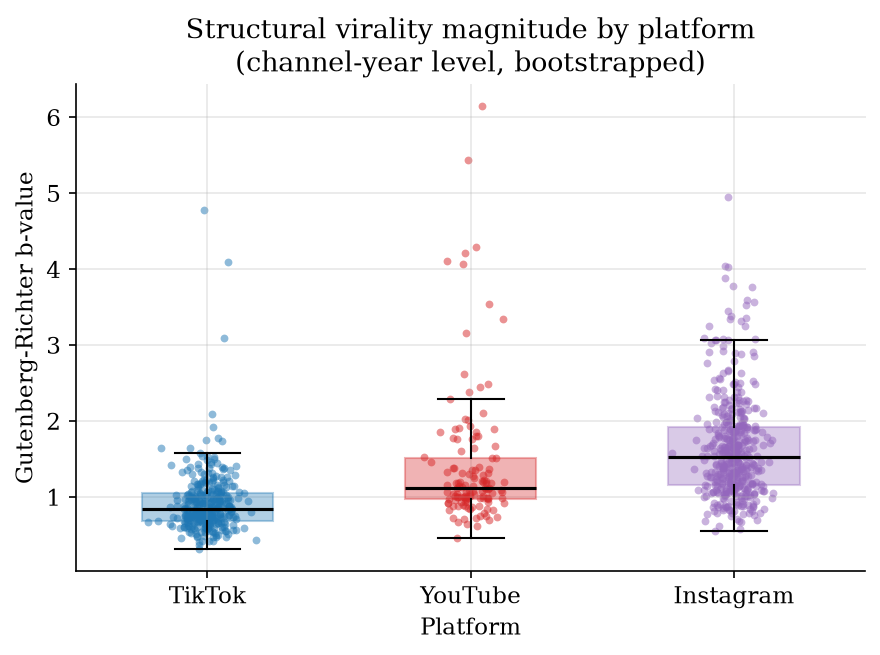

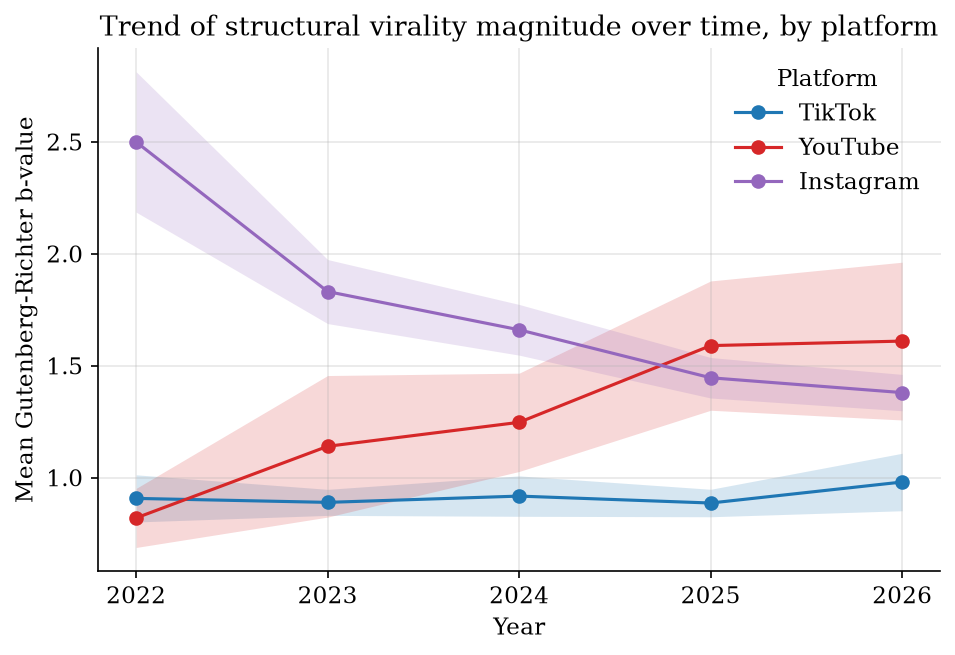

In [3]:
"""
Option B - Gutenberg-Richter b-value (structural magnitude of virality)
==========================================================================

Metric: b-value, MLE estimator (Aki, 1965), borrowed from seismology.

In the Gutenberg-Richter law, N(>=M) ~ 10^(-b*M): b is the decay rate
of the frequency-magnitude relationship. Low b => heavy tail => a few
huge "earthquakes" (viral videos) relative to the rest. High b => more
uniform distribution, fewer extreme outliers.

Technical note: the standard Aki formula uses log10 magnitudes:
    b = log10(e) / (mean(M) - M_min)
Since our log_views column is natural log, substituting M = x / ln(10)
makes the two base-conversion factors cancel out exactly, so we can
use the simplified formula directly on natural-log values:
    b = 1 / (mean(x) - x_min)

Bootstrap rationale
--------------------
b-value estimation is sensitive to sample size (few extreme points
make it noisy). We resample with replacement to a fixed N=100 per
channel-year, repeated B=100 times, and average, so channels with
different activity levels are compared at equal exposure.

Expected input
--------------
tiktok, youtube, instagram: DataFrames with columns
  ['video_id', 'publisher', 'year', 'views', 'platform']
where 'views' is already np.log(views + 1).

Plots (for paper)
-----------------
Fig. 1: Boxplot of bvalue_mean by platform -> distribution comparison
Fig. 2: bvalue_mean vs n_videos_original by platform -> confound check
Fig. 3: bvalue_mean trend over year by platform (mean +/- 95% CI)
"""

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

np.random.seed(42)

N_BOOT = 70
B_REPLICATES = 100

# --- Parametro iniziale: percentile di completezza usato come soglia x_min ---
X_MIN_QUANTILE = 0.7  # percentile basso sotto il quale i dati non sono considerati affidabili

FIGURE_DIR = "figures_B"

# ----------------------------------------------------------------------
# Publication-style matplotlib settings
# ----------------------------------------------------------------------
PLATFORM_COLORS = {
    "TikTok": "#1f77b4",
    "YouTube": "#d62728",
    "Instagram": "#9467bd",
}

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "legend.frameon": False,
})


def b_value_aki(x, x_min=None, x_min_quantile=X_MIN_QUANTILE):
    """MLE (Aki, 1965) estimate of the Gutenberg-Richter b-value.

    x: array of 'magnitudes' (here: natural-log views).
    x_min: completeness threshold (values below this are considered
    unreliable / not part of the power-law tail). If not given, it is
    computed from x_min_quantile.
    """
    if x_min is None:
        x_min = np.quantile(x, x_min_quantile)
    x_use = x[x >= x_min]
    if len(x_use) < 5:
        return np.nan
    mean_excess = x_use.mean() - x_min
    if mean_excess <= 0:
        return np.nan
    return 1.0 / mean_excess


def bootstrap_b_value(all_data, x_min_quantile=X_MIN_QUANTILE):
    records = []
    for key, grp in all_data.groupby("group_key"):
        views = grp["log_views"].values
        platform = grp["platform"].iloc[0]
        publisher = grp["publisher"].iloc[0]
        year = grp["year"].iloc[0]
        n_original = len(views)

        b_boot = []
        for _ in range(B_REPLICATES):
            sample = np.random.choice(views, size=N_BOOT, replace=True)
            b_boot.append(b_value_aki(sample, x_min_quantile=x_min_quantile))

        records.append({
            "platform": platform,
            "publisher": publisher,
            "year": year,
            "n_videos_original": n_original,
            "bvalue_mean": np.nanmean(b_boot),
            "bvalue_ci_low": np.nanpercentile(b_boot, 2.5),
            "bvalue_ci_high": np.nanpercentile(b_boot, 97.5),
        })
    return pd.DataFrame(records)


def _platform_order(summary):
    """Consistent platform ordering/colors across all figures."""
    preferred = [p for p in ["TikTok", "YouTube", "Instagram"] if p in summary["platform"].unique()]
    return preferred or sorted(summary["platform"].unique())


def _color_for(platform):
    return PLATFORM_COLORS.get(platform, "#7f7f7f")


def plot_boxplot_by_platform(summary, out_dir):
    """Fig. 1: distribution of bvalue_mean by platform (boxplot + jittered points)."""
    platforms = _platform_order(summary)
    fig, ax = plt.subplots(figsize=(6, 4.5))

    data = [summary.loc[summary["platform"] == p, "bvalue_mean"].dropna().values for p in platforms]
    bp = ax.boxplot(
        data,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.5},
    )
    # Set tick labels manually (avoids the 'labels'/'tick_labels' kwarg
    # rename across matplotlib versions: removed in 3.9+, renamed in 3.11+)
    ax.set_xticks(range(1, len(platforms) + 1))
    ax.set_xticklabels(platforms)
    for patch, p in zip(bp["boxes"], platforms):
        patch.set_facecolor(_color_for(p))
        patch.set_alpha(0.35)
        patch.set_edgecolor(_color_for(p))

    rng = np.random.default_rng(0)
    for i, (p, vals) in enumerate(zip(platforms, data), start=1):
        jitter = rng.normal(0, 0.06, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=_color_for(p), alpha=0.5, s=14, linewidths=0)

    ax.set_ylabel("Gutenberg-Richter b-value")
    ax.set_xlabel("Platform")
    ax.set_title("Structural virality magnitude by platform\n(channel-year level, bootstrapped)")

    fig.tight_layout()
    fig.show()



def plot_bvalue_trend_by_year(summary, out_dir):
    """Fig. 3: yearly mean bvalue_mean +/- 95% CI, by platform."""
    platforms = _platform_order(summary)
    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    for p in platforms:
        sub = summary[summary["platform"] == p].dropna(subset=["bvalue_mean"]).copy()
        sub["year"] = sub["year"].astype(int)
        grouped = sub.groupby("year")["bvalue_mean"].agg(["mean", "std", "count"]).reset_index()
        grouped["se"] = grouped["std"] / np.sqrt(grouped["count"])
        grouped["ci95"] = 1.96 * grouped["se"]
        grouped = grouped.sort_values("year")

        ax.plot(grouped["year"], grouped["mean"], marker="o", color=_color_for(p), label=p)
        ax.fill_between(
            grouped["year"],
            grouped["mean"] - grouped["ci95"],
            grouped["mean"] + grouped["ci95"],
            color=_color_for(p), alpha=0.18, linewidth=0,
        )

    ax.set_xlabel("Year")
    ax.set_ylabel("Mean Gutenberg-Richter b-value")
    ax.set_title("Trend of structural virality magnitude over time, by platform")
    ax.set_xticks(sorted(summary["year"].astype(int).unique()))
    ax.legend(title="Platform", loc="best")

    fig.tight_layout()
    fig.show()


def generate_plots(summary, out_dir=FIGURE_DIR):
    os.makedirs(out_dir, exist_ok=True)
    plot_boxplot_by_platform(summary, out_dir)
    plot_bvalue_trend_by_year(summary, out_dir)
    print(f"\nSaved 3 figures (PDF + PNG) to '{out_dir}/'")


def main(x_min_quantile=X_MIN_QUANTILE):

    all_data = pd.concat([tiktok, youtube, instagram], ignore_index=True)
    all_data = all_data.rename(columns={"views": "log_views"})
    all_data["group_key"] = (
        all_data["platform"].astype(str) + "_" +
        all_data["publisher"].astype(str) + "_" +
        all_data["year"].astype(str)
    )

    # --- 2. Bootstrap the b-value metric per channel-year ---
    summary = bootstrap_b_value(all_data, x_min_quantile=x_min_quantile)
    summary["year"] = summary["year"].astype(str)

    print("Preview of channel-year summary table:")
    print(summary.head())
    print(f"\nTotal channel-years analyzed: {len(summary)}")
    print(f"Percentile di completezza (x_min) usato: {round(x_min_quantile * 100)}° percentile")

    # --- 3. Mixed model: b-value ~ platform + year + activity, random effect per channel ---
    model_A = smf.mixedlm(
        "bvalue_mean ~ platform + year + n_videos_original",
        data=summary,
        groups=summary["publisher"],
    ).fit()

    print("\n" + "=" * 70)
    print("OPTION A - Gutenberg-Richter b-value")
    print("=" * 70)
    print(model_A.summary())

    summary.to_csv("virality_option_A_summary.csv", index=False)
    print("\nSaved: virality_option_A_summary.csv")

    # --- 4. Plots for the paper ---
    generate_plots(summary)


if __name__ == "__main__":
    main(x_min_quantile=X_MIN_QUANTILE)